# Choosing the active space

<div style="border-left:4px solid #6d3f8c;background:#6d3f8c1a;border-radius:4px;margin:1em 0;"><div style="background:#6d3f8c;color:#ffffff;padding:0.35em 0.8em;font-weight:600;">Chapter focus</div>

<div style="padding:0.1em 1em;">

Which electrons and orbitals must the calculation treat explicitly?

</div>

</div>

## Learning objectives

After completing this chapter, you will be able to:

- Explain why strongly correlated systems require more than one determinant.
- Distinguish inactive, active, and virtual orbitals.
- Select a valence active space with QDK/Chemistry.
- Explain how natural orbitals and reduced density matrices support active-space selection.
- Explain how orbital entropies can refine an active-space choice.
- Evaluate the tradeoff between active-space accuracy and problem size.

<div style="border-left:4px solid #005a8d;background:#005a8d1a;border-radius:4px;margin:1em 0;"><div style="background:#005a8d;color:#ffffff;padding:0.35em 0.8em;font-weight:600;">Lab notebook assignment</div>

<div style="padding:0.1em 1em;">

Complete *lab notebook active space*.
Record the evidence used to select the active space, not only the final orbital and electron counts.
Explain what the energy comparison establishes within the chosen basis and identify the energy that will serve as the algorithmic reference.

</div>

</div>

## Before you begin

This course requires a Python environment with the `qdk-chemistry[jupyter]` package.

`qdk-chemistry` ships compiled binaries for Linux, macOS on Apple silicon, and Windows on x86-64. On Windows on Arm, run this course inside WSL. Run the cell below to check the current environment.

In [ ]:
from _unit import check_env

check_env()

## Setting up

The cell below imports the QDK/Chemistry pieces this chapter uses and quiets the solver logs.

In [ ]:
from dataclasses import dataclass
from typing import TYPE_CHECKING, cast

from qdk_chemistry.algorithms import create
from qdk_chemistry.data import Orbitals, Structure, Wavefunction
from qdk_chemistry.data.symmetry import SymmetryLabel, axes
from qdk_chemistry.utils import Logger, compute_valence_space_parameters
from tutorial_orbital_coordinates import (
    NaturalOrbitalCoordinateMinimizationResult,
    coordinate_minimize_natural_orbital_coefficient_norm,
)

if TYPE_CHECKING:
    from matplotlib.figure import Figure

from tutorial_choose_active_space import create_stretched_n2_structure

structure = create_stretched_n2_structure()
charge = 0
spin_multiplicity = 1
basis_set = "cc-pvdz"

scf_solver = create("scf_solver", "qdk")
hartree_fock_energy, hartree_fock_wavefunction = scf_solver.run(
    structure,
    charge=charge,
    spin_multiplicity=spin_multiplicity,
    basis_or_guess=basis_set,
)

## The limits of one determinant

As *the previous chapter explains*, the [Hartree–Fock method](https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method) restricts the [wavefunction](https://en.wikipedia.org/wiki/Wave_function) to one optimized [Slater determinant](https://en.wikipedia.org/wiki/Slater_determinant).
This determinant represents one [electron configuration](https://en.wikipedia.org/wiki/Electron_configuration), a pattern of occupied spin orbitals introduced in *Orbitals and determinants*.
This description is often a useful starting point near an equilibrium geometry, where one configuration dominates the ground-state wavefunction, as discussed for N<sub>2</sub> in *Specify the molecular system* chapter.
Stretching a chemical bond can make several configurations similar in energy because electrons can no longer be assigned adequately to one fixed pattern of occupied and unoccupied [molecular orbitals](https://en.wikipedia.org/wiki/Molecular_orbital_theory).
The need to combine these multiple important configurations is called [static correlation](https://en.wikipedia.org/wiki/Electronic_correlation).
The stretched N<sub>2</sub> geometry has been selected to demonstrate this regime.
The correlated calculations below evaluate static correlation by constructing a multi-determinant wavefunction and measuring orbital-occupation entropies.

A [configuration interaction](https://en.wikipedia.org/wiki/Configuration_interaction) (CI) calculation addresses this limitation by calculating a wavefunction expanded in multiple Slater determinants:

$$
\vert \Psi \rangle = \sum_I c_I \vert \Phi_I \rangle,
$$

where $\vert \Phi_I \rangle$ is determinant $I$ and $c_I$ is its coefficient.
Every determinant $\Phi_I$, including $\Phi_{\mathrm{HF}}$, is constructed from one allowed choice of occupied spin orbitals.
Different choices represent different electron configurations.
Full configuration interaction (FCI) includes every determinant consistent with a chosen finite orbital basis and fixed $(n_\alpha,n_\beta)$ sector.
It therefore gives the exact eigenvalues of the finite-basis Hamiltonian in that sector, up to numerical solver tolerance.
For this 14-electron calculation in 28 `cc-pvdz` spatial orbitals, the $(n_\alpha,n_\beta)=(7,7)$ sector contains

$$
\binom{28}{7}\binom{28}{7}
= 1{,}401{,}950{,}721{,}600
\approx 1.4\times 10^{12}
$$

determinants.
At a fixed electron-to-orbital ratio, this count grows exponentially with the number of orbitals, making full-basis FCI impractical for large systems.
An [active-space model](https://en.wikipedia.org/wiki/Complete_active_space) controls that cost by allowing occupations to vary only among selected orbitals, trading some model accuracy for a smaller determinant space.
If that model contains $n_o$ active spatial orbitals, $n_\alpha$ active $\alpha$ electrons, and $n_\beta$ active $\beta$ electrons, the choices of occupied $\alpha$ and $\beta$ spin orbitals give

$$
N_{\mathrm{det}} = \binom{n_o}{n_\alpha}\binom{n_o}{n_\beta}.
$$

## The active space

<div style="text-align:center;">

![The spatial molecular orbitals are partitioned into inactive orbitals that remain doubly occupied and contribute to the core energy, active orbitals whose occupations vary among determinants and whose correlation is treated explicitly, and virtual orbitals that remain empty and are excluded from the correlated calculation.](attachment:tutorial_qpe_orbital_partition.png)

*An active-space calculation varies occupations only among the active orbitals; inactive and virtual occupations remain fixed across determinants.*

</div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why can an inactive orbital still contribute to the molecular energy?</summary>

<div style="padding:0.1em 1em;">

An inactive spatial orbital remains doubly occupied in every determinant.
Its electrons and their interactions contribute to the core part of the active-space Hamiltonian even though the calculation does not vary their occupations.

</div>

</details></div>

A complete active space containing $n_e$ active electrons in $n_o$ active spatial orbitals is written CAS$(n_e,n_o)$.
Complete active space configuration interaction (CASCI) forms every determinant consistent with those active electron and orbital counts while keeping the molecular orbitals fixed.
Unlike complete active space self-consistent field (CASSCF), CASCI does not reoptimize the orbitals.

A useful first choice is a generous valence space containing orbitals on both sides of the occupied–virtual boundary.
The `compute_valence_space_parameters()` function determines the numbers of valence electrons and valence spatial orbitals from the Hartree–Fock wavefunction and molecular charge.
The *qdk_valence selector* uses those numbers to construct an initial active space from orbitals near the HOMO–LUMO gap.
The highest occupied molecular orbital (HOMO) and lowest unoccupied molecular orbital (LUMO) define the boundary between occupied and virtual orbitals in the Hartree–Fock reference.
Orbitals near this boundary are the most accessible when low-energy configurations redistribute electrons, so a valence window around the gap is a useful generous starting space for the correlated calculation:
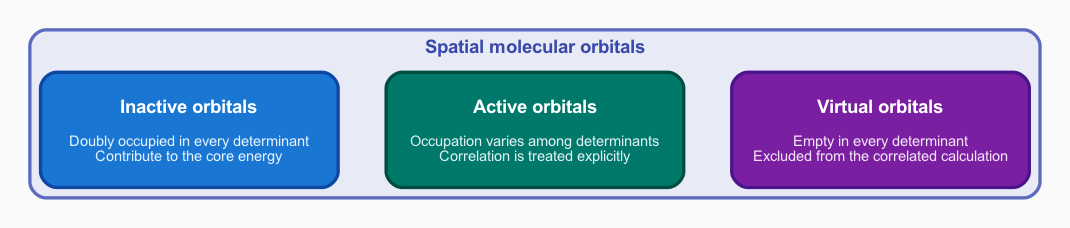

In [ ]:
num_valence_electrons, num_valence_orbitals = compute_valence_space_parameters(
    hartree_fock_wavefunction, charge
)
valence_selector = create(
    "active_space_selector",
    "qdk_valence",
    num_active_electrons=num_valence_electrons,
    num_active_orbitals=num_valence_orbitals,
)
valence_wavefunction = valence_selector.run(hartree_fock_wavefunction)

# Restricted alpha and beta channels contain the same spatial-orbital indices,
# so read one channel to count each spatial orbital once.
alpha_channel = SymmetryLabel([axes.alpha()])
valence_indices = list(
    valence_wavefunction.get_orbitals().active_indices().indices(alpha_channel)
)
num_valence_alpha, num_valence_beta = (
    valence_wavefunction.get_active_num_electrons()
)

For this restricted calculation, matching $\alpha$ and $\beta$ channels describe the same spatial orbitals, so the code reads one channel and counts each spatial orbital once.
The script reports the resulting active electron and orbital counts and the zero-based indices of the active orbitals.
Use these values with the total number of `cc-pvdz` molecular orbitals from *Describing the molecule* to determine the initial partitioning of inactive, active, and virtual orbitals.

## A correlated active-space wavefunction

The active-space selector labels orbitals but does not determine how strongly each orbital participates in correlation.
That evidence must come from a correlated wavefunction.
The script constructs the molecular Hamiltonian in the initial valence space and solves it with the *MACIS CASCI implementation*:

In [ ]:
hamiltonian_constructor = create("hamiltonian_constructor")
casci_solver = create(
    "multi_configuration_calculator",
    "macis_cas",
    # Tight convergence keeps the RDM-derived natural subspaces stable
    # across numerical backends before their orbital gauge is selected.
    ci_residual_tolerance=1e-10,
    # autoCAS entropies require both one- and two-particle RDMs.
    calculate_one_rdm=True,
    calculate_two_rdm=True,
)

valence_hamiltonian = hamiltonian_constructor.run(
    valence_wavefunction.get_orbitals()
)
valence_energy, valence_casci_wavefunction = casci_solver.run(
    valence_hamiltonian,
    num_valence_alpha,
    num_valence_beta,
)
num_valence_determinants = len(valence_casci_wavefunction.get_coefficients())

Using the determinant-count formula above, the initial valence space in this example is small enough to include every determinant rather than approximating the wavefunction with a selected subset.
Larger active-space studies often use selected CI (SCI) to obtain approximate active-space diagnostics at lower cost, but that additional approximation is unnecessary here.

The `calculate_one_rdm` and `calculate_two_rdm` settings request the one- and two-particle reduced density matrices (RDMs).
An RDM summarizes the parts of the many-electron wavefunction needed to describe one- or two-particle properties.
The spin-resolved one-particle RDM tracks $\alpha$ and $\beta$ occupations separately, and its diagonal gives the expected occupation of each spin orbital.
A corresponding diagonal element of the two-particle RDM gives the joint occupation of a pair of spin orbitals.
Each determinant assigns every spatial orbital one of four *local occupation states*: empty, occupied by one $\alpha$ electron, occupied by one $\beta$ electron, or doubly occupied.
Here, a local occupation state describes only one orbital, not the complete electronic state of the molecule.
For these occupation quantities, determinant $I$ contributes with weight $\lvert c_I\rvert^2$, the squared magnitude of its coefficient in the correlated wavefunction.
Together, the RDM elements collect these contributions into the probabilities of the four local occupation states.
If the important determinants give an orbital the same occupation, one probability dominates; if they assign different occupations, the probabilities spread among several local states.

## Natural-orbital transformation

Different sets of molecular orbitals can describe the same active space.
Changing to natural orbitals changes the individual orbital shapes but not the exact CASCI energy for that active space.
Orbital-resolved quantities, however, can change because they describe the chosen orbital representation.

Natural orbitals diagonalize the one-particle RDM.
Their eigenvalues are natural-orbital occupation numbers between zero and two for spatial orbitals.
In this basis, the off-diagonal elements vanish, so each occupation number is associated directly with one natural orbital rather than being mixed among several orbitals.
Occupations near two identify nearly doubly occupied orbitals, occupations near zero identify nearly empty orbitals, and fractional occupations can reveal orbitals that require multiple electron configurations.
Natural orbitals provide a useful convention in which the one-particle occupations are directly associated with individual orbitals before applying the orbital-resolved entropy criterion.

The supported *qdk_natural_orbitals transformation* uses the one-particle RDM from the initial CASCI wavefunction.
It rotates the active orbitals into the natural-orbital representation described above.
The script then rebuilds and resolves the initial valence-space Hamiltonian so that both RDMs and the orbital diagnostics are expressed consistently in the natural-orbital representation:

In [ ]:
# Rotate the valence orbitals using the CASCI one-particle RDM so each
# natural orbital has a well-defined correlated occupation.
natural_orbital_localizer = create("orbital_localizer", "qdk_natural_orbitals")
natural_orbital_wavefunction = natural_orbital_localizer.run(
    valence_casci_wavefunction,
    valence_indices,
    valence_indices,
)

# Rebuild and solve in the rotated basis so the RDMs and orbital entropies
# describe the same natural-orbital representation.
natural_orbital_hamiltonian = hamiltonian_constructor.run(
    natural_orbital_wavefunction.get_orbitals()
)
natural_orbital_energy, natural_orbital_casci_wavefunction = casci_solver.run(
    natural_orbital_hamiltonian,
    num_valence_alpha,
    num_valence_beta,
)
# Store ordinary Python floats rather than library scalar types so the
# values can be printed and passed to the visualization notebook directly.
orbital_entropies = [
    float(value)
    for value in natural_orbital_casci_wavefunction.get_single_orbital_entropies()
]

The two CASCI energies should agree to the displayed precision because both calculations span the same complete active space.
The second calculation is needed for the orbital-resolved selection evidence, not to lower the energy.

## Active-space refinement with orbital entropies

The single-orbital entropy used here is the [von Neumann entropy](https://en.wikipedia.org/wiki/Von_Neumann_entropy) of the reduced density matrix for one spatial orbital.
Its eigenvalues are the probabilities $\omega_{a,i}$ of the four local occupation states, so the entropy has the Shannon form

$$
s_i^{(1)} = -\sum_{a=1}^{4} \omega_{a,i}\ln\omega_{a,i}.
$$

These probabilities come from diagonal elements of the spin-resolved one- and two-particle RDMs.
If $n_{i\alpha}$ and $n_{i\beta}$ are the one-particle occupations and $d_i$ is the *double-occupancy probability*—the probability that the $\alpha$ and $\beta$ spin orbitals belonging to spatial orbital $i$ are occupied simultaneously—then

$$
\begin{aligned}
\omega_{\mathrm{empty},i} &= 1-n_{i\alpha}-n_{i\beta}+d_i, \\
\omega_{\alpha,i} &= n_{i\alpha}-d_i, \\
\omega_{\beta,i} &= n_{i\beta}-d_i, \\
\omega_{\mathrm{double},i} &= d_i.
\end{aligned}
$$

The one-particle occupation $n_{i\alpha}$ includes both the $\alpha$-only and doubly occupied cases, so subtracting $d_i$ isolates the $\alpha$-only probability; the same reasoning gives the $\beta$-only probability.
The empty probability is the remainder after accounting for either spin occupation, with $d_i$ added back because double occupation was subtracted twice.
The four probabilities therefore sum to one.

An entropy near zero means that one local occupation state consistently dominates.
A larger entropy means that the orbital changes among several local occupation states across the important determinants.
In other words, the important determinants assign different occupations to this orbital together with corresponding occupation differences elsewhere in the active space.
This correlated variation makes the orbital a stronger candidate for explicit treatment.
These high-entropy orbitals carry the strongest static-correlation signal because their occupations vary among the important determinants.
Freezing a high-entropy orbital would prevent its occupation from changing with the occupations of the other orbitals and would therefore remove an important part of the multi-configurational wavefunction.
By contrast, a low-entropy orbital remains close to one local occupation state and is a better candidate to freeze as inactive or virtual.
QDK/Chemistry evaluates these probabilities and entropies from the RDMs stored in the CASCI wavefunction.
Automated active-space selection (autoCAS) uses orbital entropies to identify which orbitals should remain active.
The resulting data flow is therefore: the correlated wavefunction determines the local-state probabilities, those probabilities determine one entropy for each orbital, and autoCAS uses the entropies to select the orbitals in the active space.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why does autoCAS require a correlated calculation before it can select orbitals?</summary>

<div style="padding:0.1em 1em;">

The selector uses single-orbital entropies derived from local occupation probabilities.
Those probabilities require one- and two-particle RDMs from a correlated wavefunction; a Hartree–Fock determinant alone does not provide the required correlation evidence.

</div>

</details></div>

The QDK/Chemistry *qdk_autocas_eos selector* sorts the orbital entropies and selects a high-entropy group separated from the remaining orbitals by a sufficiently large gap.
The thresholds are configurable; see *Active-space selection* for their defaults and use with less clearly separated entropy values.
The selector then repartitions the orbitals according to the selected group:

In [ ]:
# autoCAS uses the RDM-derived orbital entropies to retain the orbitals that
# carry the strongest correlation in a smaller active space.
autocas_selector = create("active_space_selector", "qdk_autocas_eos")
refined_wavefunction = autocas_selector.run(natural_orbital_casci_wavefunction)
refined_orbitals = refined_wavefunction.get_orbitals()

# Summarize the inactive, selected active, and virtual spatial-orbital spaces.
alpha_channel = SymmetryLabel([axes.alpha()])
refined_indices = list(refined_orbitals.active_indices().indices(alpha_channel))
if not refined_indices:
    raise RuntimeError(
        "autoCAS selected no active orbitals. Set refined_wavefunction to "
        "natural_orbital_wavefunction to retain the complete valence space, "
        "or adjust the autoCAS thresholds before continuing."
    )
inactive_indices = list(refined_orbitals.inactive_indices().indices(alpha_channel))
num_refined_alpha, num_refined_beta = (
    refined_wavefunction.get_active_num_electrons()
)
num_refined_electrons = num_refined_alpha + num_refined_beta
num_refined_orbitals = len(refined_indices)
num_virtual_orbitals = (
    refined_orbitals.get_num_molecular_orbitals()
    - len(inactive_indices)
    - num_refined_orbitals
)

# Natural occupations can be degenerate, leaving the corresponding orbital
# vectors free to rotate. Choose that gauge only after autoCAS has selected
# the final active subspace, because lambda belongs to its mapped Hamiltonian.
coordinate_minimization = coordinate_minimize_natural_orbital_coefficient_norm(
    valence_casci_wavefunction,
    refined_orbitals,
    valence_indices,
)
refined_orbitals = coordinate_minimization.orbitals

.. The figure intentionally reveals the selected group before the later
 observed-result question. Showing the entropy gap is necessary to teach how
 autoCAS makes the selection, which outweighs preserving the answer as a surprise.

<div style="text-align:center;">

![Entropy-ranked candidate orbitals. Selected orbitals 8, 7, 5, 6, 9, and 4 have entropies of approximately 0.966, 0.966, 0.964, 0.964, 0.554, and 0.548. Excluded orbitals 3 and 2 have entropies of approximately 0.030 and 0.022. A dashed vertical cut separates the sixth and seventh entropy ranks.](attachment:tutorial_qpe_orbital_entropy.png)

*Candidate natural orbitals sorted by decreasing single-orbital entropy. autoCAS retains the high-entropy group to the left of the dashed cut.*

</div>

The asterisks in the script output identify the selected orbitals.
The selected high-entropy group determines the refined active space.
Equal natural-orbital occupations can leave the corresponding orbital vectors free to rotate within a degenerate subspace.
The script chooses a reproducible representation within each selected degenerate block by coordinate-minimizing the mapped Hamiltonian coefficient norm $\lambda=\sum_\ell\lvert h_\ell\rvert$, without changing the orbital subspace or its exact CASCI energy.
Among the unselected orbitals, those below the occupied–virtual boundary of the reference determinant become inactive, while those above the boundary become virtual.
Freezing these low-entropy orbitals is still an approximation because low entropy does not mean that their correlation contribution is exactly zero, so the energy comparison below measures part of its cost.
Their entropies are small rather than exactly zero, and allowing excitations involving them can still lower the correlated energy.
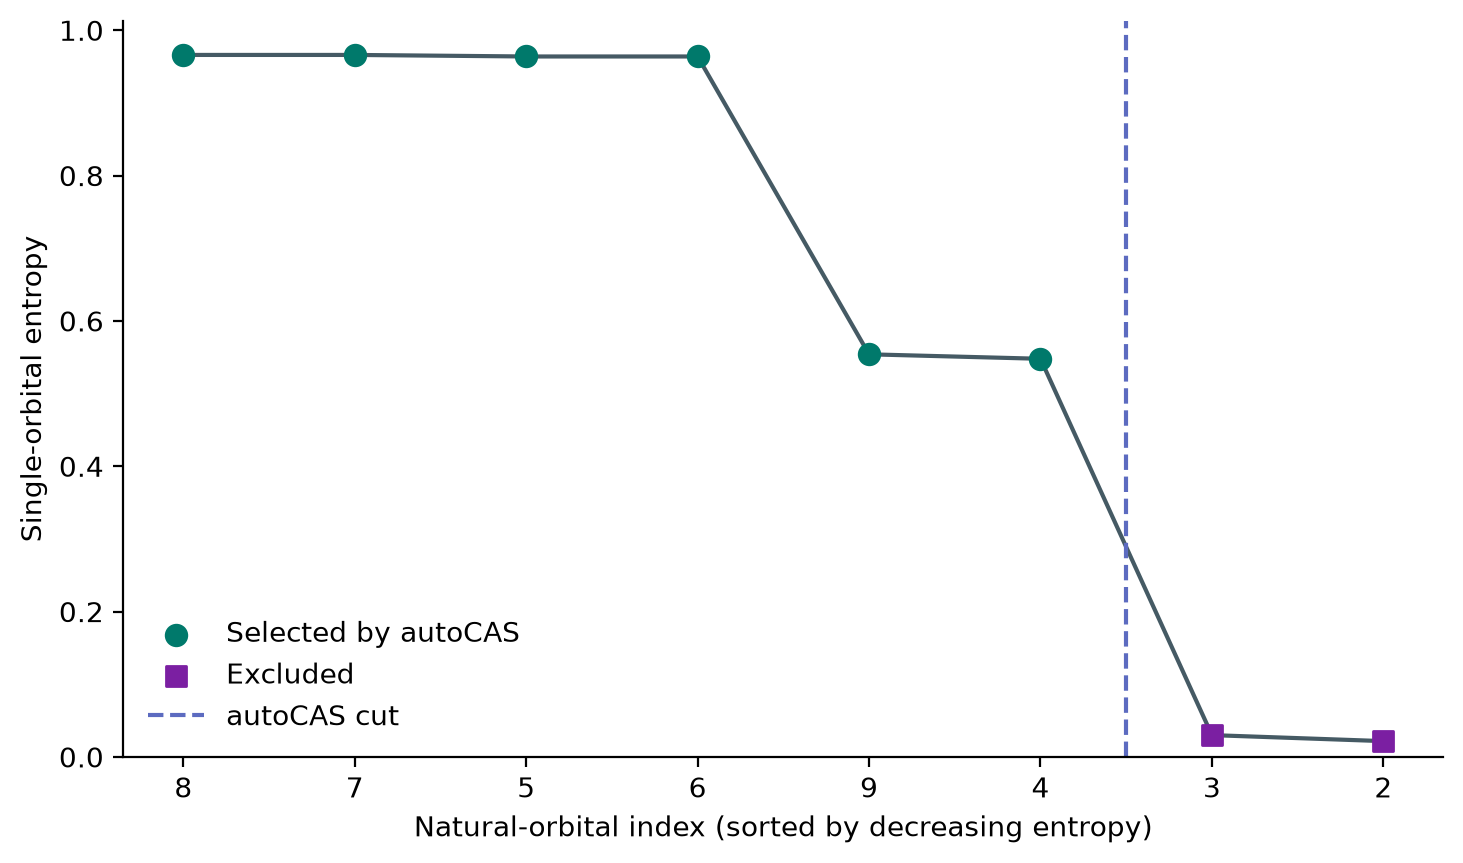

## The algorithmic reference

The script finishes by solving the refined active-space Hamiltonian with CASCI:

In [ ]:
refined_hamiltonian = hamiltonian_constructor.run(refined_orbitals)
refined_energy, refined_casci_wavefunction = casci_solver.run(
    refined_hamiltonian,
    num_refined_alpha,
    num_refined_beta,
)
num_refined_determinants = len(refined_casci_wavefunction.get_coefficients())

The resulting determinant count quantifies the reduction in problem size for the quantum-computing stages of the tutorial.
The final CASCI energy is the exact ground-state energy of the selected active-space Hamiltonian, up to numerical solver tolerance, and will be the *algorithmic reference energy* for state preparation and phase estimation.
CASCI is a full configuration-interaction calculation within the selected active space, but it is not the exact energy of N<sub>2</sub> in the full `cc-pvdz` orbital space: fixing the inactive orbitals as doubly occupied and the virtual orbitals as empty excludes correlation involving those orbitals.

## The active-space choice

The initial valence space includes more orbitals than the refined active space so that the correlated calculation can first measure the entropy of every candidate orbital.
The refinement then uses this evidence to decide which orbital occupations must remain variable and which can be frozen.
Freezing additional orbital occupations cannot lower the CASCI energy.
It leaves the energy unchanged only if the removed determinants contribute nothing to the larger-space ground state; otherwise, as in this example, the energy increases.
The script reports the observed energy increase when reducing the active space.

The observed increase quantifies correlation excluded when reducing the initial valence space.
This active-space model error is separate from the $1\ \mathrm{m}E_{\mathrm{h}}$ teaching target, which applies only to the later quantum algorithm's agreement with the compact-model CASCI reference.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why should the energy increase caused by active-space refinement not be judged against the $1\ \mathrm{m}E_{\mathrm{h}}$ teaching target?</summary>

<div style="padding:0.1em 1em;">

The energy increase measures correlation excluded when orbital occupations are frozen during active-space refinement.
The $1\ \mathrm{m}E_{\mathrm{h}}$ target applies later when comparing the phase-estimation energy with the exact CASCI energy of the same selected-space Hamiltonian.
These comparisons measure different approximations.

</div>

</details></div>

For this tutorial, the refined active space is accepted as a compact model because it retains the orbitals with the strongest entropy-based correlation evidence while producing a tractable Hamiltonian for validating the quantum workflow.
The energy difference from the initial valence-space calculation remains documented as model error.
The next chapter will determine how the selected active spatial orbitals are represented by qubits.

## Count the determinants

The refined active space is CAS$(6,6)$: six electrons in six spatial orbitals, so three $\alpha$ and three $\beta$ electrons. The $\alpha$ and $\beta$ occupations are chosen independently of each other.

Fix the function below so that it returns the number of determinants this active space contains, then run the cell.

In [ ]:
from math import comb

from _unit import exercise


@exercise
def determinant_count():
    alpha = comb(6, 3)
    beta = comb(6, 3)
    return alpha

**Hint**

Every way of placing the three $\alpha$ electrons can be paired with every way of placing the three $\beta$ electrons, so the two counts combine multiplicatively rather than additively.

**Solution**

Return the product of the two counts:

```python
return alpha * beta
```

$\binom{6}{3}=20$, so the refined space holds $20\times20=400$ determinants, down from the 3,136 of the initial CAS$(10,8)$ valence space.

## Running the calculation

The cells above have already run the workflow. Use their output to answer the questions below.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;What initial valence space and determinant count did the script construct?</summary>

<div style="padding:0.1em 1em;">

The script reports ten active electrons in eight active spatial orbitals, written CAS$(10,8)$, with five $\alpha$ and five $\beta$ active electrons.
The active orbital indices are 2 through 9.
Of the 28 `cc-pvdz` molecular orbitals, indices 0 and 1 are initially inactive and the remaining 18 are virtual.
The determinant count is $\binom{8}{5}\binom{8}{5}=3136$.

</div>

</details></div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Which orbitals did autoCAS retain, and how much did refinement reduce the problem size?</summary>

<div style="padding:0.1em 1em;">

Orbitals 4 through 9 have entropies from approximately 0.548 to 0.966, separated by a large gap from the remaining values of approximately 0.030 or less.
autoCAS retains these six orbitals in CAS$(6,6)$, containing three $\alpha$ and three $\beta$ active electrons.
The refined partition has four inactive orbitals, six active orbitals, and 18 virtual orbitals.
Its determinant count is $\binom{6}{3}\binom{6}{3}=400$, compared with 3,136 determinants in the initial valence space.

</div>

</details></div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Did the natural-orbital transformation change the CASCI energy?</summary>

<div style="padding:0.1em 1em;">

No change appears at the displayed precision.
The script reports the signed energy change after the transformation, which is consistent with numerical roundoff near zero.
Both calculations span the same complete active subspace, so changing the orbital representation does not change the exact CASCI energy within that subspace.

</div>

</details></div>

Record the orbital representation, initial and refined active-space sizes, selection evidence, determinant counts, and both CASCI energies in the *active-space section of the lab notebook*.
Use the final selected-space energy as the algorithmic reference, while retaining the larger-space result as evidence of the correlation excluded by the compact model.

## Candidate-orbital visualization

Download and open `tutorial_choose_active_space.ipynb` in Visual Studio Code.
Choose **Select Kernel**, select **Python Environments**, and choose the `.venv` environment created in *Before you begin*.
If `.venv` does not appear, open the Command Palette, run **Developer: Reload Window**, and reopen the kernel selector.
Then select **Run All** to execute the shared active-space calculation and generate an interactive molecular-orbital viewer.

The Jupyter notebook displays every candidate natural orbital from the initial valence space, including orbitals that autoCAS did not retain.
Use the viewer to inspect the following information:

- **Orbital menu**
  Selects each candidate natural orbital for comparison.
  The menu follows increasing molecular-orbital index, which corresponds here to decreasing natural occupation.
  The menu is not ordered by entropy.
- **Isosurface**
  Traces points where the orbital wavefunction has a chosen positive or negative value, revealing its lobes, nodes, and spatial extent.
  The surface itself does not encode occupation or entropy.
- **Natural occupation**
  Reports the average number of electrons in the spatial orbital.
  A value near two indicates an almost always doubly occupied orbital, a value near zero indicates an almost always empty orbital, and an intermediate value indicates variable occupation across the correlated wavefunction.
- **Single-orbital entropy and autoCAS selection**
  Reports the uncertainty in the orbital's local occupation and whether autoCAS retained it.
  Larger entropy indicates stronger coupling to the occupations of the other active orbitals.

autoCAS selects the strongly coupled group from gaps in the orbital entropies, not from orbital shapes or a cutoff applied to the natural occupations.
Use the shapes as aids to chemical interpretation, but defend the final active space using the numerical occupation and entropy evidence in the overlays.

The molecular viewer needs values of each orbital's spatial wavefunction on a three-dimensional grid. The next cell evaluates all candidate natural orbitals on such a grid and stores the sampled values as cube data.

Each orbital is annotated with its natural occupation, single-orbital entropy, and autoCAS selection status so that you can examine the spatial and numerical evidence together. Generating the orbital grids may take a little longer than the preceding calculation.

In [ ]:
from qdk_chemistry.utils.cubegen import generate_cubefiles_from_orbitals

natural_orbitals = natural_orbital_casci_wavefunction.get_orbitals()
occupation_alpha, occupation_beta = (
    natural_orbital_casci_wavefunction.get_active_orbital_occupations()
)

# Occupation arrays use active-space positions, while cube-file labels use
# the original molecular-orbital indices; this dictionary connects them.
active_position = {
    orbital_index: position for position, orbital_index in enumerate(valence_indices)
}
raw_cube_data = generate_cubefiles_from_orbitals(
    orbitals=natural_orbitals,
    grid_size=(30, 30, 30),
    margin=10.0,
    indices=valence_indices,
)

cube_data = {}
for raw_label, cube_file in raw_cube_data.items():
    # Cube labels number orbitals from one, while QDK/Chemistry indices start
    # from zero, so convert before looking up occupations and entropies.
    orbital_index = int(raw_label.split("_")[1]) - 1
    position = active_position[orbital_index]
    # Add the alpha and beta occupations to report the total occupation of
    # each spatial orbital in the viewer.
    occupation = float(occupation_alpha[position]) + float(occupation_beta[position])
    cube_data[f"Orbital {orbital_index}"] = {
        "data": cube_file,
        "info": {
            "Occupation": f"{occupation:.3f}",
            "Entropy": f"{orbital_entropies[position]:.3f}",
            "Selected by autoCAS": "yes" if orbital_index in refined_indices else "no",
        },
    }

print(f"Generated cube data for {len(cube_data)} candidate orbitals.")

## Inspect the natural orbitals

Launch the interactive molecular viewer and use its orbital menu to move through the candidate natural orbitals. For each orbital, inspect the isosurface together with the displayed "occupation", "entropy", and "selected by autoCAS" information. Compare the selected orbitals with the nearly doubly occupied and nearly empty orbitals that were excluded.

In [ ]:
from qdk.widgets import MoleculeViewer

MoleculeViewer(
    molecule_data=structure.to_xyz(),
    cube_data=cube_data,
)

Use the viewer to inspect the following information:

- **Orbital menu** selects each candidate natural orbital for comparison. The menu follows increasing molecular-orbital index, which corresponds here to decreasing natural occupation. The menu is not ordered by entropy.
- **Isosurface** traces points where the orbital wavefunction has a chosen positive or negative value, revealing its lobes, nodes, and spatial extent. The surface itself does not encode occupation or entropy.
- **Natural occupation** reports the average number of electrons in the spatial orbital. A value near two indicates an almost always doubly occupied orbital, a value near zero indicates an almost always empty orbital, and an intermediate value indicates variable occupation across the correlated wavefunction.
- **Single-orbital entropy and autoCAS selection** report the uncertainty in the orbital's local occupation and whether autoCAS retained it. Larger entropy indicates stronger coupling to the occupations of the other active orbitals.

autoCAS selects the strongly coupled group from gaps in the orbital entropies, not from orbital shapes or a cutoff applied to the natural occupations. Use the shapes as aids to chemical interpretation, but defend the final active space using the numerical occupation and entropy evidence in the overlays.

## Interpret the active-space choice

Identify which visual features distinguish nearly doubly occupied orbitals, high-entropy orbitals with strongly coupled occupations, and nearly empty orbitals. Then explain why autoCAS retains the selected group while excluding the other candidate orbitals.

Treat the orbital shapes as aids to chemical interpretation rather than as the selection rule. Defend the refined active-space choice using the occupation and entropy overlays, and record your explanation in the active-space section of the lab notebook.

## Further reading

- *Orbital localization and transformation*
- *Active-space selection*
- *Multi-configuration calculations*
- *Wavefunctions*